# Project Name: CAPM for 10 U.S. Stocks
Eileen QIN Yuxuan, MMath Keble College, Oxford University

## 1- Choose 10 U. S. Stocks from different industries
### Principles:
- Diversified industry structure (avoids high industry beta correlation)
- High stock liquidity (stable data)
- Mature company structure (bet and alpha are more meaningful)
### List:
Therefore we choose the following stocks:

|GICS   |Ticker |Full Name|Comment    |
|:-------|:----|:-------|:-------|
|8- Information Technology     |AAPL|Apple   |High Stock Liquidity  |
|9- Communication Services   |GOOG|Google   |Tech Industry. High β value   |
|4- Consumer Discretionary     |AMZN|Amazon   |High Growth  |
|5- Consumer Staples    |PG|P&G   |Defensive Industries |
|7- Financials     |JPM|J. P. Morgan   |High β value, Bank  |
|6- Health Care    |JNJ|Johnson & Johnson   |Low β value, Stable  |
|3- Industrials     |CAT|Caterpillar   |Eco Cycle Related |
|1- Energy     |XOM|Exxon Mobil   |Strong Periodicity  |
|2- Materials     |NUE|Nucor   |Traditional Cyclical Industries  |
|10- Utilities   |DUK|Duke Energy   |Defensive Industries  |

## 2- Get 5 years stock data from yahoo finance:

In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 设置参数
tickers = ["AAPL", "GOOG", "AMZN", "PG", "JPM", "JNJ", "CAT", "XOM", "NUE", "DUK"]
market_ticker = "^GSPC"  # S&P 500 指数
start_date = "2020-01-01"
end_date = "2024-12-31"

# 2. 下载数据
data = yf.download(
    tickers + [market_ticker], start=start_date, end=end_date, auto_adjust=False
)["Adj Close"]

# 3. 把下载的数据以 DataFrame 的形式保存到本地 ../data/data.csv
data.to_csv("../data/data.csv")

[*********************100%***********************]  11 of 11 completed


In [ ]:
# 4. 计算日收益率 (Simple Returns)
returns = data.pct_change().dropna()

# 5. 获取无风险利率 (假设日化后的短期国债利率，简单处理为0，随后可使用FRED数据)
# # FRED API Key applied: e806f46613853a7112ffad1476bc151f
rf = 0

# 6. 计算超额收益 (Excess Returns)
excess_returns = returns.subtract(rf, axis=0)
market_excess = excess_returns[market_ticker]
stock_excess = excess_returns[tickers]

Ticker          AAPL      AMZN       CAT       DUK      GOOG       JNJ  \
Date                                                                     
2020-01-03 -0.009722 -0.012139 -0.013884  0.000664 -0.004907 -0.011578   
2020-01-06  0.007968  0.014886 -0.000673  0.004867  0.024657 -0.001247   
2020-01-07 -0.004703  0.002092 -0.013213 -0.006275 -0.000624  0.006107   
2020-01-08  0.016087 -0.007809  0.008881  0.001440  0.007880 -0.000138   
2020-01-09  0.021240  0.004799 -0.002506  0.002433  0.011045  0.002967   
...              ...       ...       ...       ...       ...       ...   
2024-12-23  0.003065  0.000622 -0.001776  0.002586  0.015703  0.005538   
2024-12-24  0.011478  0.017729  0.005966  0.003777  0.008062  0.003992   
2024-12-26  0.003176 -0.008732 -0.001224 -0.006057 -0.002379 -0.001851   
2024-12-27 -0.013242 -0.014534 -0.006156  0.000277 -0.015525 -0.003641   
2024-12-30 -0.013263 -0.010950 -0.005070 -0.005815 -0.006957 -0.011789   

Ticker           JPM       NUE       

In [12]:
# 7. 进行 CAPM 回归分析
results = []
for ticker in tickers:
    y = stock_excess[ticker]
    # 显式给常数项命名，避免潜在的名称冲突
    X = sm.add_constant(market_excess)
    model = sm.OLS(y, X).fit()

    # 使用标签名称来获取参数
    # 'const' 是 sm.add_constant 默认生成的名称
    # market_ticker 是你定义的变量名 '^GSPC'
    alpha = model.params["const"]
    beta = model.params[market_ticker]

    results.append(
        {
            "Ticker": ticker,
            "Alpha": alpha,
            "Beta": beta,
            "R-squared": model.rsquared,
            "P-value": model.pvalues[market_ticker],  # 同样建议用标签获取 p 值
        }
    )
    # 转换结果为 DataFrame
results_df = pd.DataFrame(results)
print("--- CAPM 回归结果 ---")
print(results_df)

--- CAPM 回归结果 ---
  Ticker     Alpha      Beta  R-squared        P-value
0   AAPL  0.000526  1.173257   0.624674  4.066262e-269
1   GOOG  0.000400  1.126548   0.551173  2.164054e-220
2   AMZN  0.000320  1.081025   0.411471  1.546943e-146
3     PG  0.000117  0.547995   0.312336  4.362677e-104
4    JPM  0.000135  1.080653   0.502618  2.120924e-192
5    JNJ -0.000100  0.482823   0.274835   1.336668e-89
6    CAT  0.000461  0.952529   0.391332  2.302893e-137
7    XOM  0.000277  0.831374   0.266397   1.919024e-86
8    NUE  0.000364  1.140366   0.345727  1.157547e-117
9    DUK  0.000060  0.640975   0.307880  2.519755e-102


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12000\39272013.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Ticker", y="Beta", data=results_df, palette="viridis")


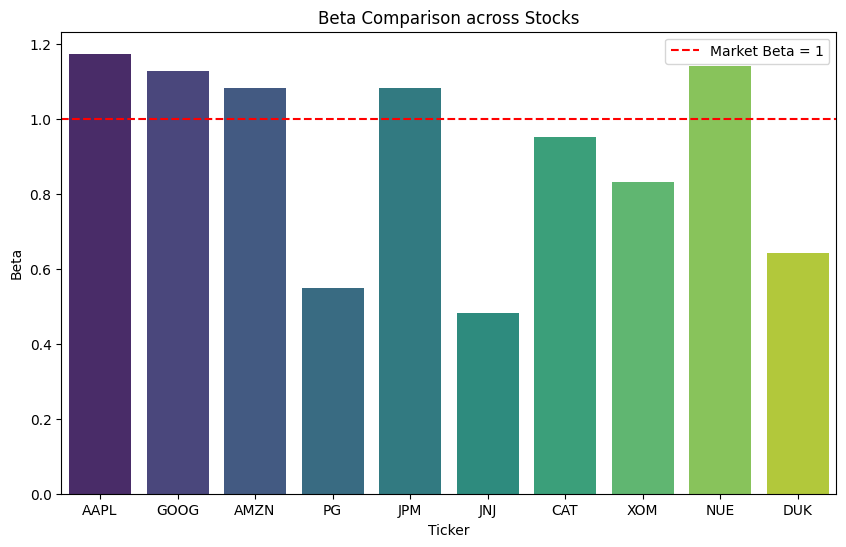

In [13]:
# 8. 可视化：Beta 条形图
plt.figure(figsize=(10, 6))
sns.barplot(x="Ticker", y="Beta", data=results_df, palette="viridis")
plt.axhline(1, color="red", linestyle="--", label="Market Beta = 1")
plt.title("Beta Comparison across Stocks")
plt.legend()
plt.show()

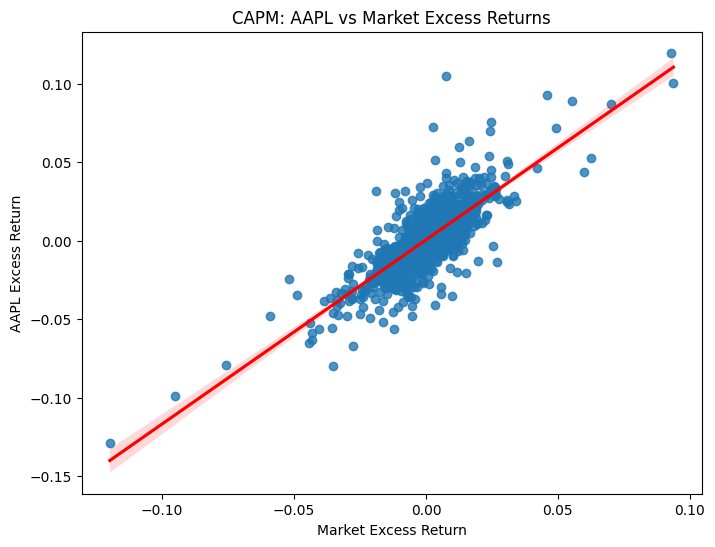

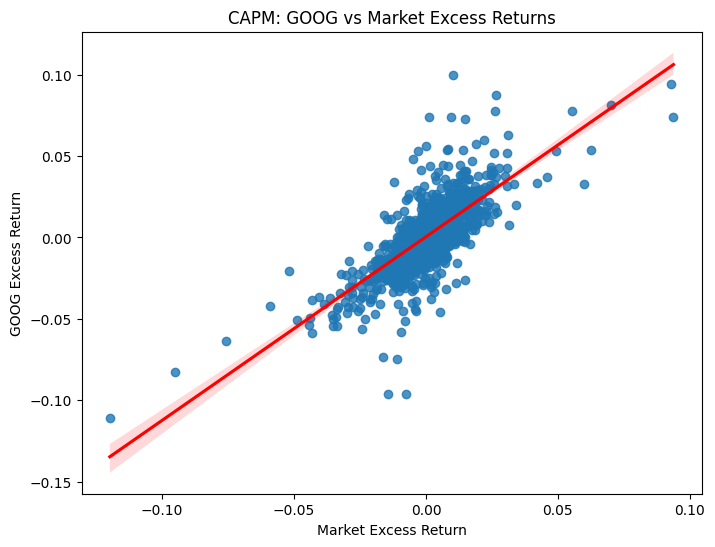

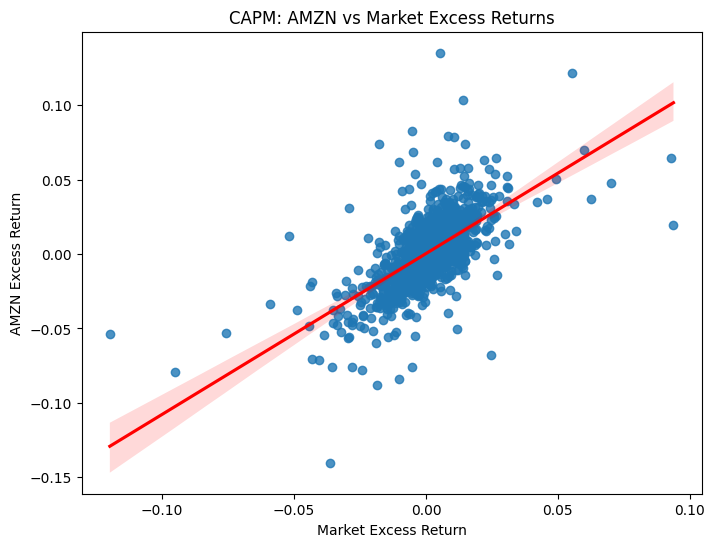

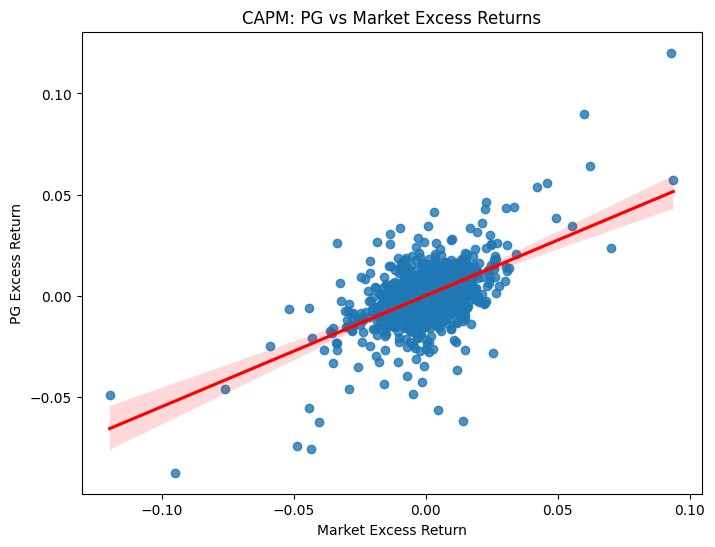

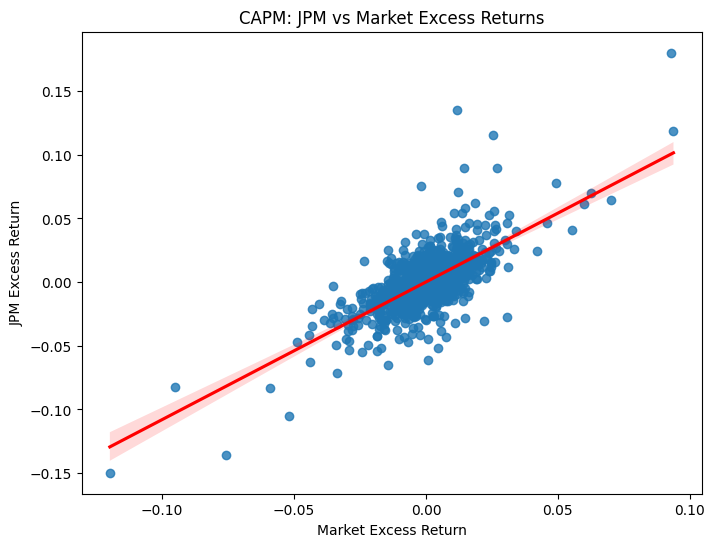

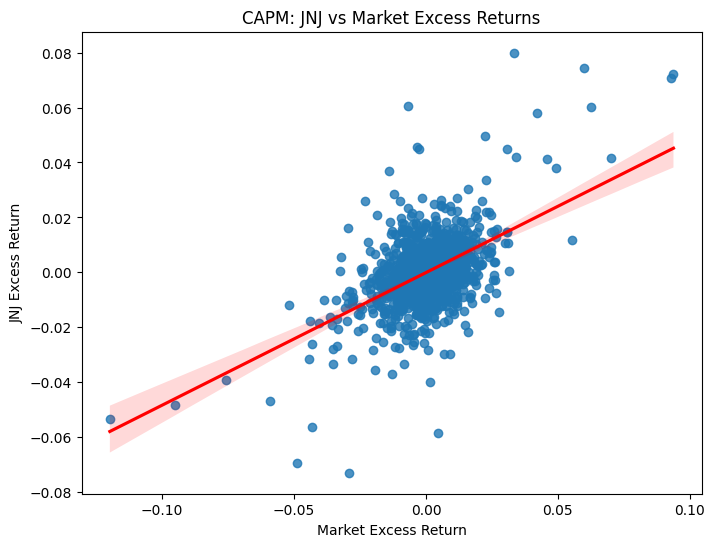

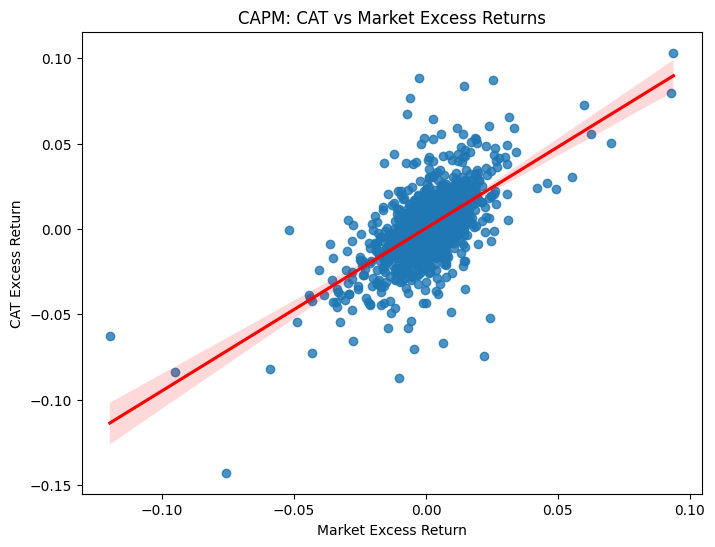

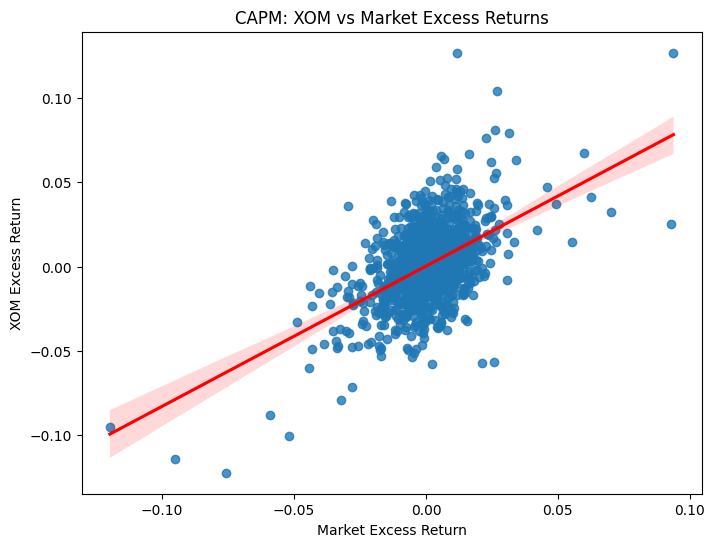

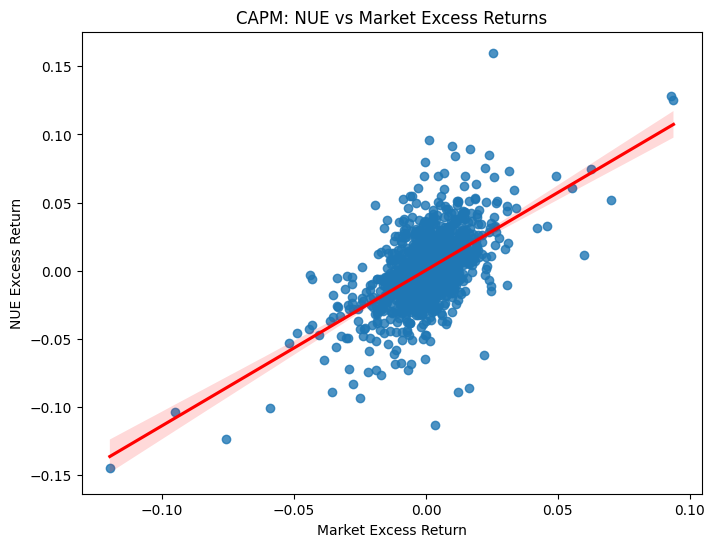

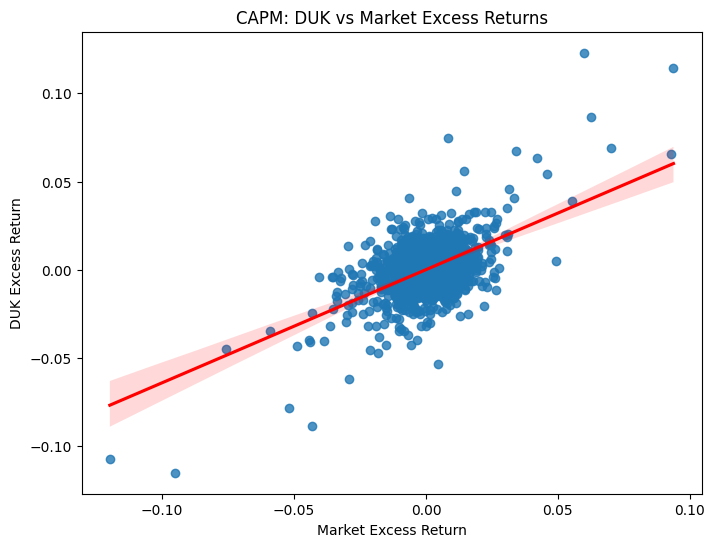

In [14]:
# 9. 可视化：散点图 + 回归线 (遍历10个ticker)
for ticker in tickers:
    plt.figure(figsize=(8, 6))
    sns.regplot(x=market_excess, y=stock_excess[ticker], line_kws={"color": "red"})
    plt.title(f"CAPM: {ticker} vs Market Excess Returns")
    plt.xlabel("Market Excess Return")
    plt.ylabel(f"{ticker} Excess Return")
    plt.show()

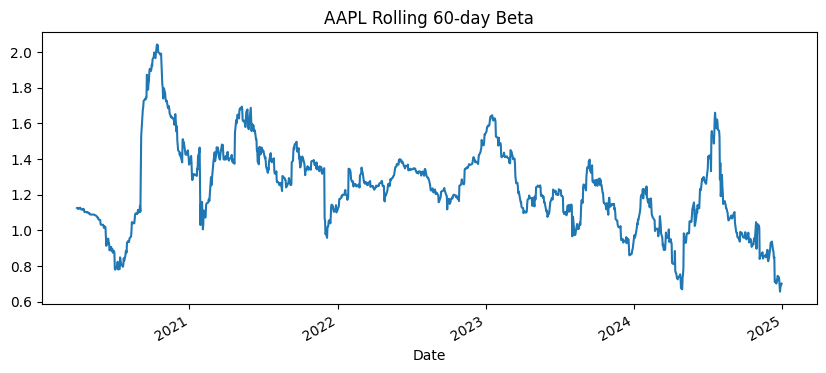

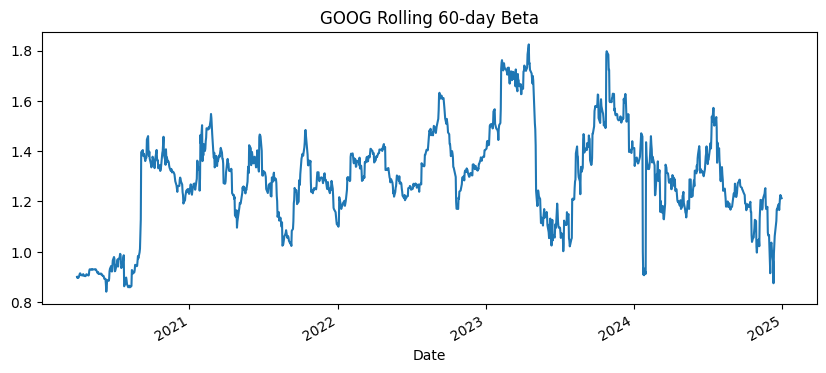

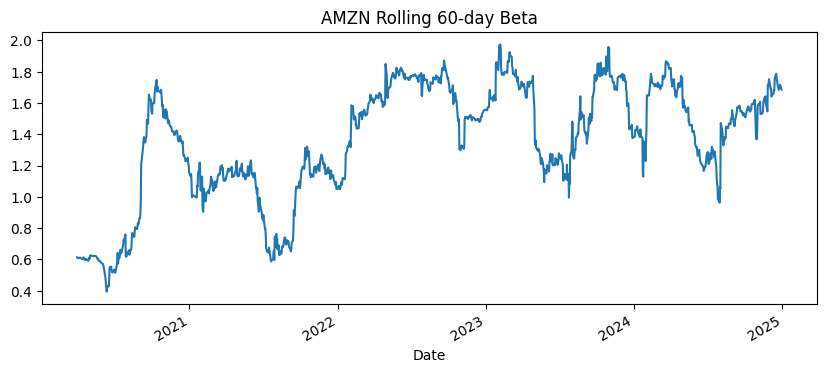

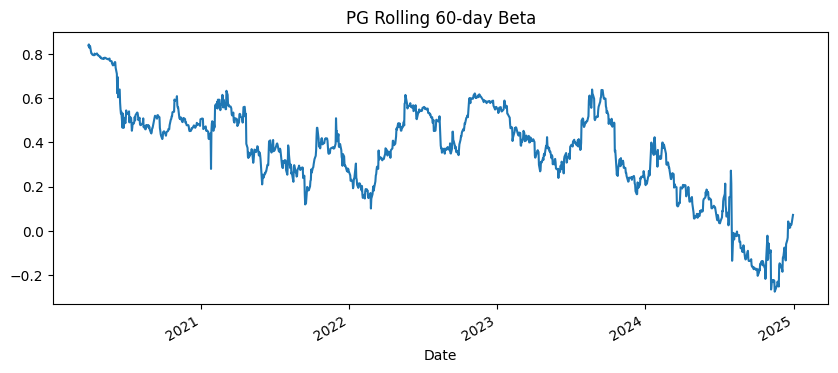

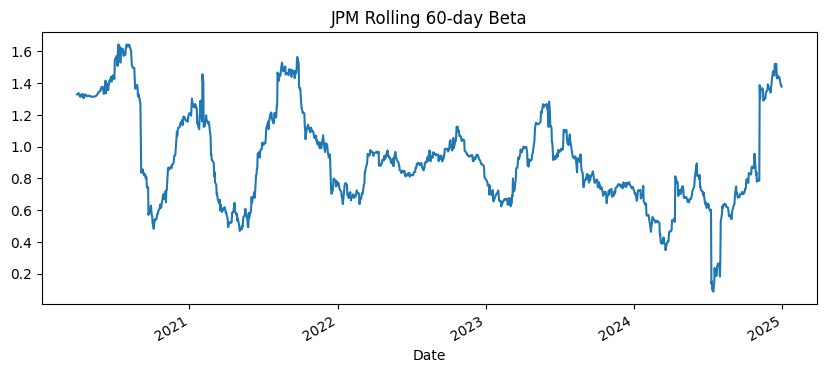

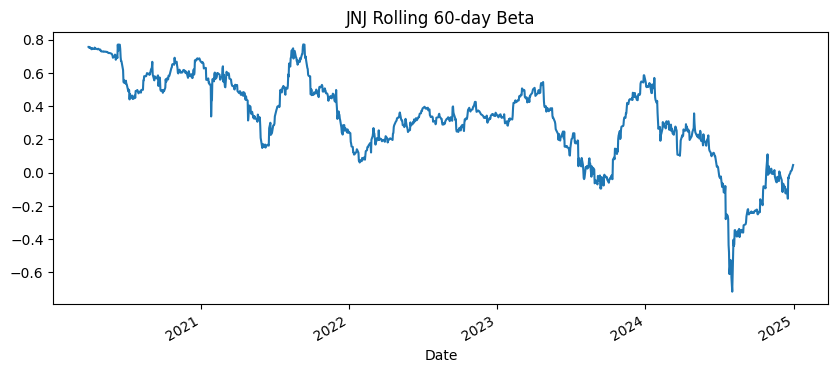

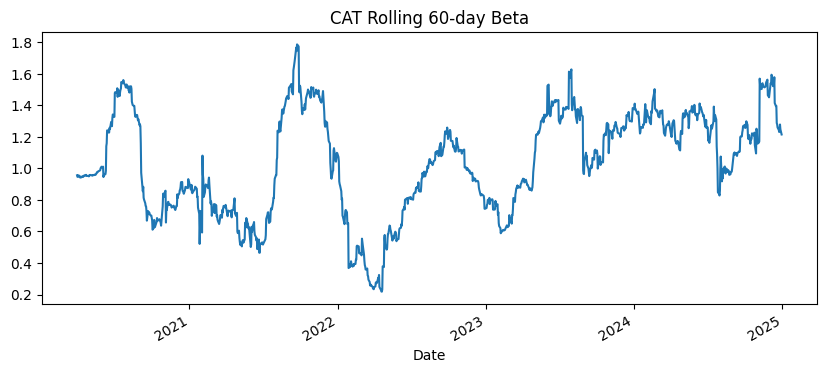

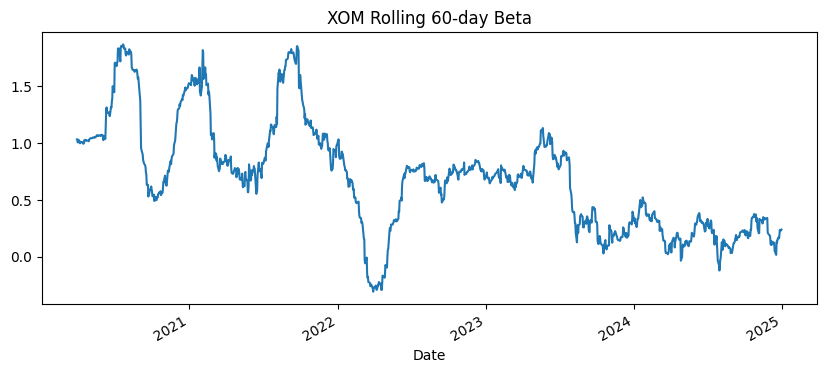

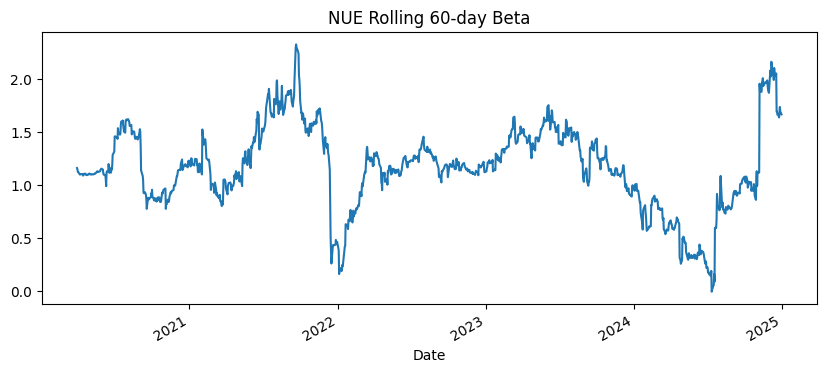

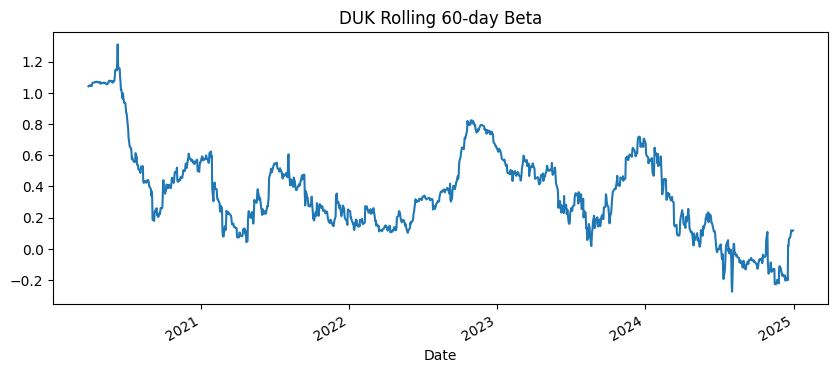

In [15]:
# 9. 滚动 Beta (遍历10个ticker, 查看稳定性)
for ticker in tickers:
    rolling_beta = (
        stock_excess[ticker]
        .rolling(window=60)
        .apply(
            lambda x: np.cov(x, market_excess.loc[x.index])[0, 1]
            / np.var(market_excess.loc[x.index])
        )
    )
    rolling_beta.plot(figsize=(10, 4), title=f"{ticker} Rolling 60-day Beta")
    plt.show()

--- Summary for AAPL ---
                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.625
Model:                            OLS   Adj. R-squared:                  0.624
Method:                 Least Squares   F-statistic:                     2087.
Date:                Wed, 13 May 2026   Prob (F-statistic):          4.07e-269
Time:                        12:22:27   Log-Likelihood:                 3749.6
No. Observations:                1256   AIC:                            -7495.
Df Residuals:                    1254   BIC:                            -7485.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      

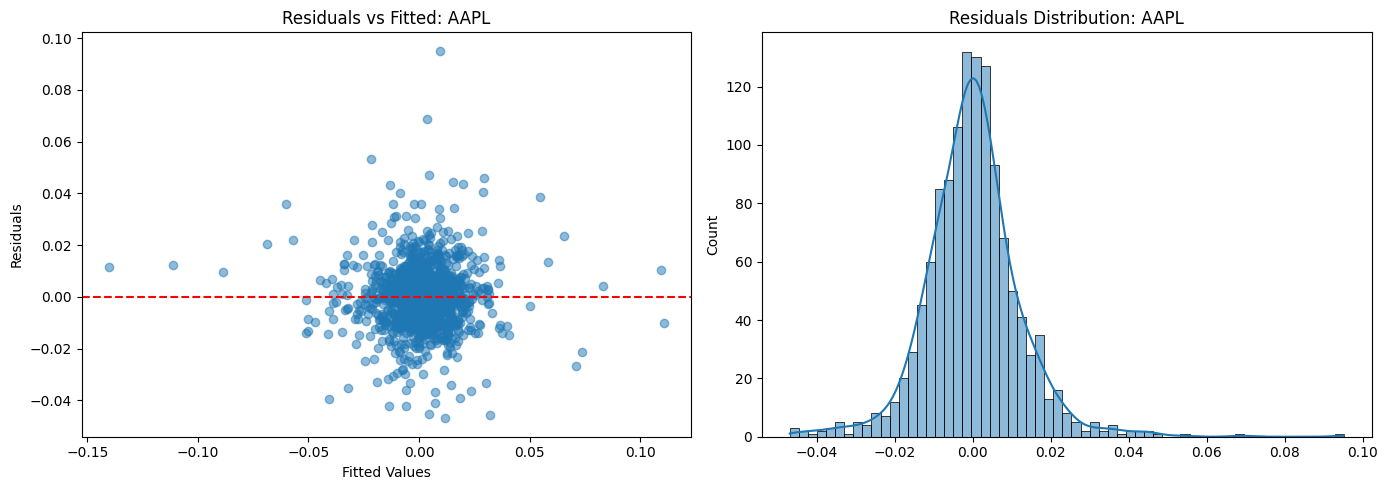

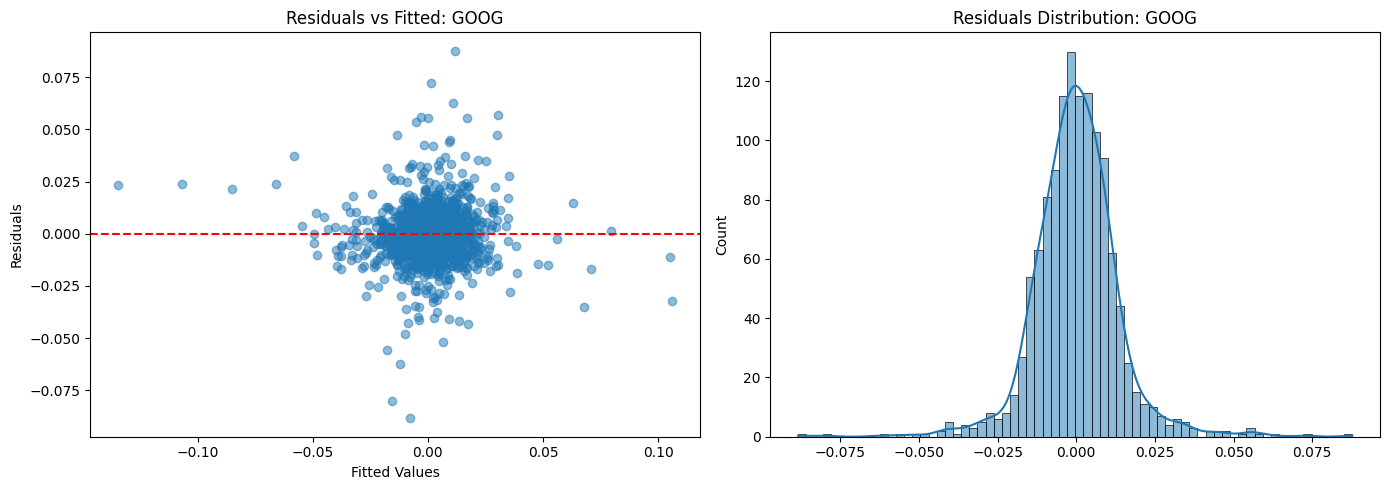

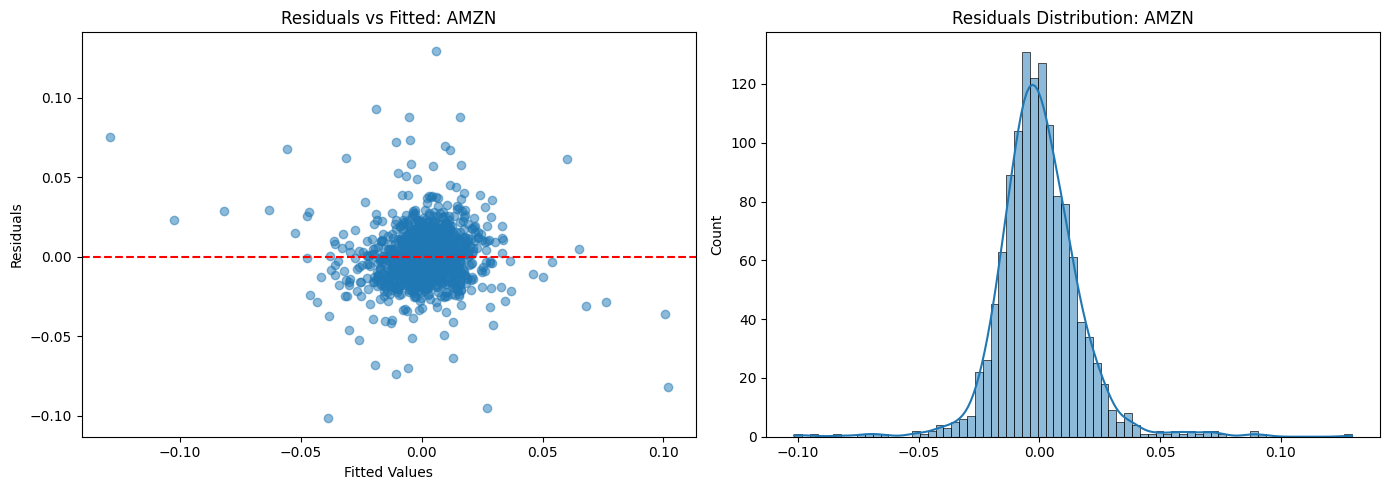

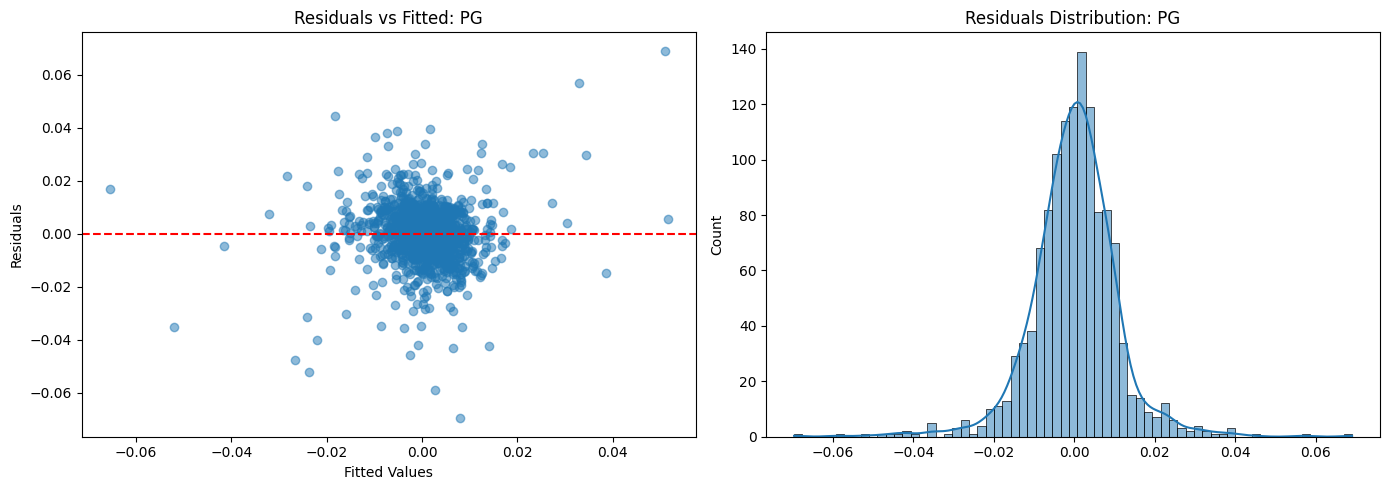

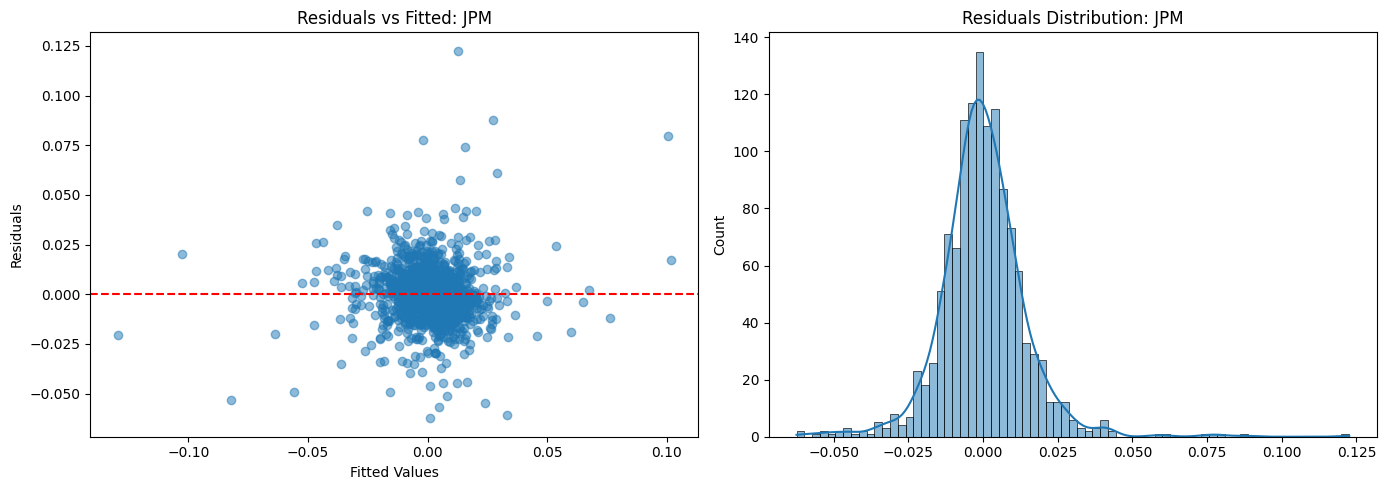

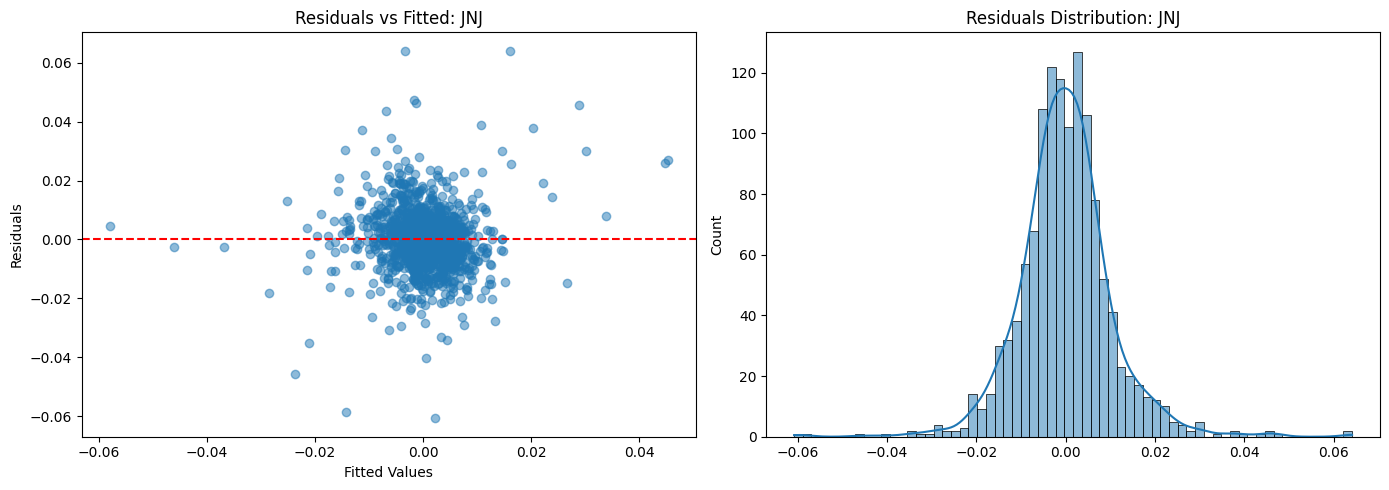

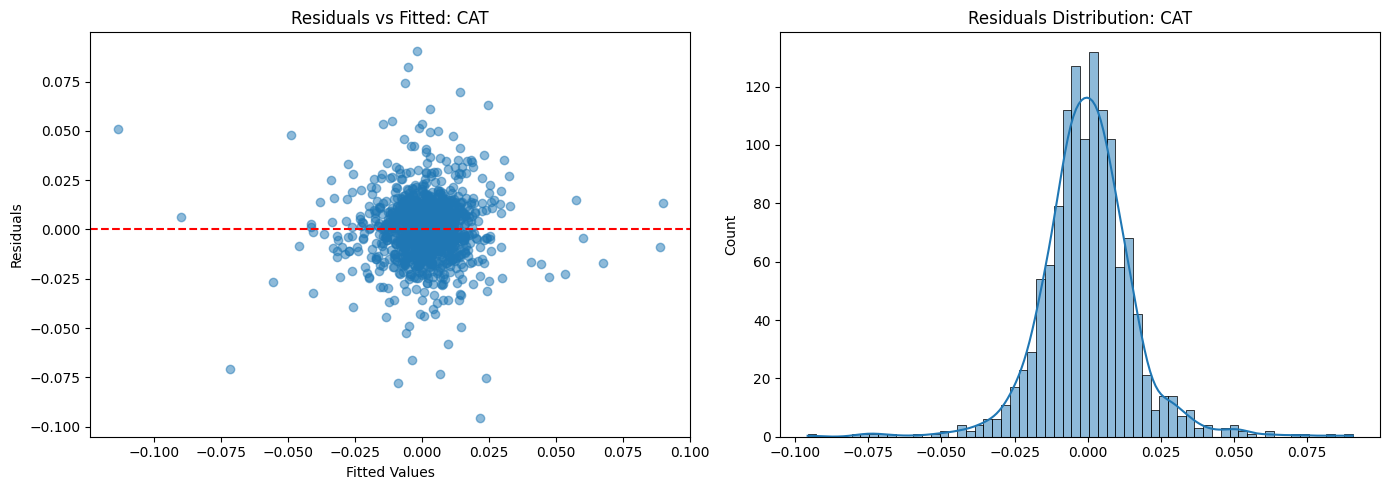

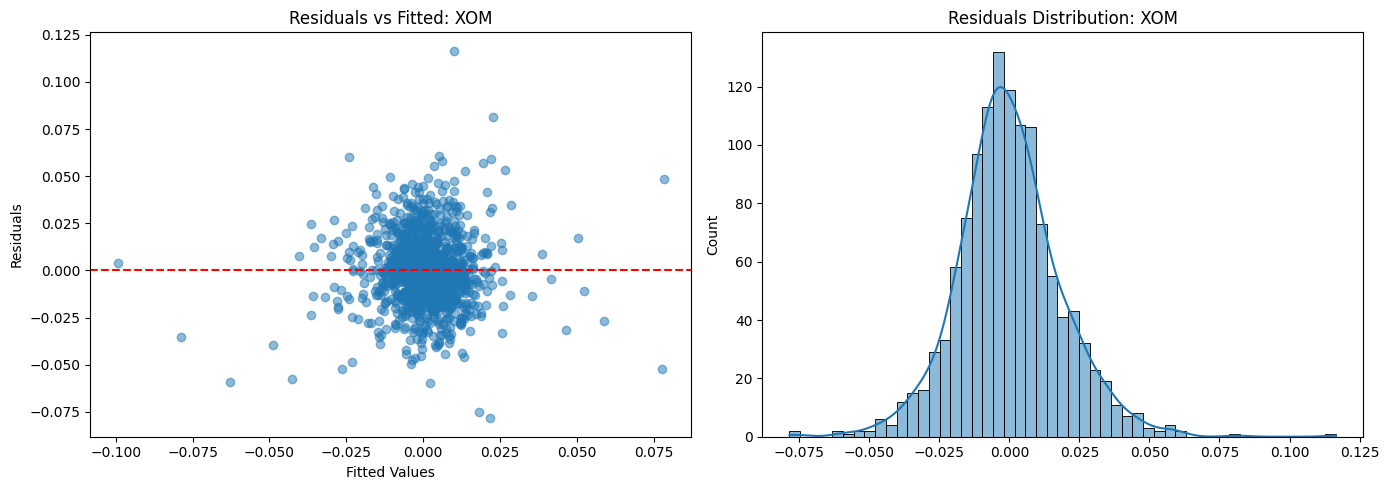

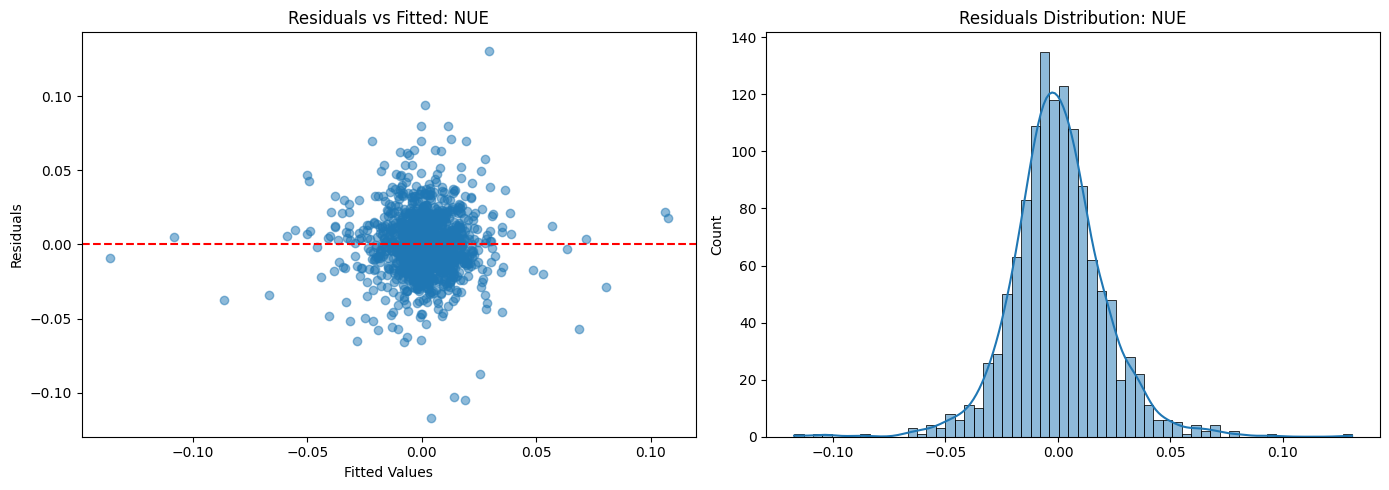

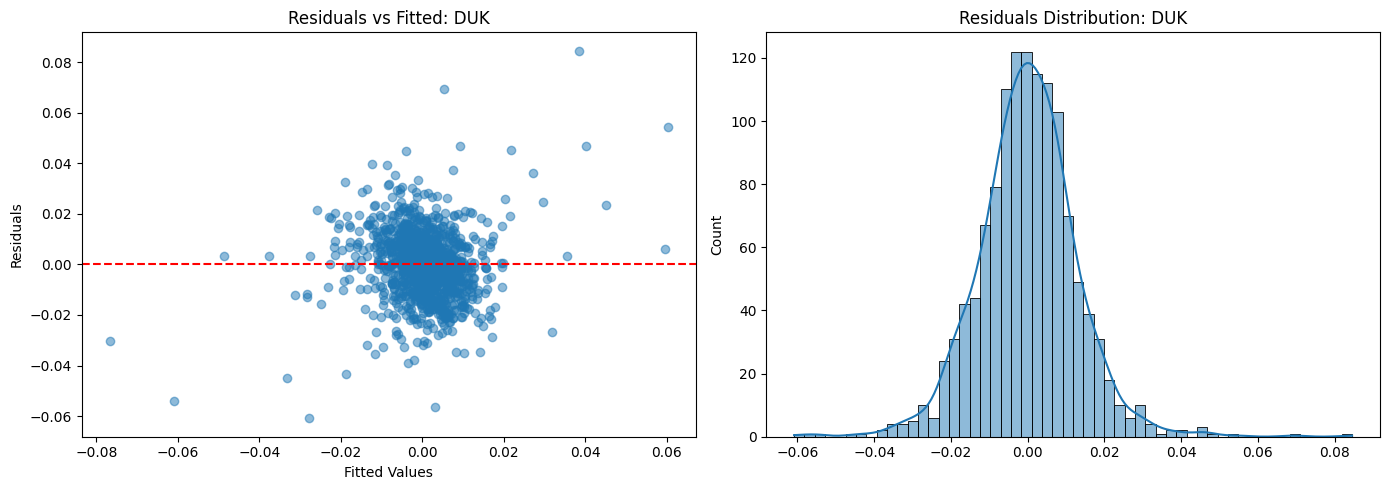

In [16]:
# 10. In-sample Regression Summary
# 在循环中添加打印 summary，查看每一只股票的完整统计数据
for ticker in tickers:
    y = stock_excess[ticker]
    X = sm.add_constant(market_excess)
    model = sm.OLS(y, X).fit()

    # 打印每一只股票的完整摘要
    print(f"--- Summary for {ticker} ---")
    print(model.summary())

# 11. Residual Plots
# 绘制残差散点图和直方图
for ticker in tickers:
    y = stock_excess[ticker]
    X = sm.add_constant(market_excess)
    model = sm.OLS(y, X).fit()
    residuals = model.resid  # 获取残差数据

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 子图1：残差散点图 (观察是否存在异方差性)
    axes[0].scatter(model.fittedvalues, residuals, alpha=0.5)
    axes[0].axhline(0, color="red", linestyle="--")
    axes[0].set_title(f"Residuals vs Fitted: {ticker}")
    axes[0].set_xlabel("Fitted Values")
    axes[0].set_ylabel("Residuals")

    # 子图2：残差直方图 (观察是否接近正态分布)
    sns.histplot(residuals, kde=True, ax=axes[1])
    axes[1].set_title(f"Residuals Distribution: {ticker}")

    plt.tight_layout()
    plt.show()

## Things Look at:
1- Which stocks have beta above or below 1? 

- 含义：Beta > 1 表示股票相对于市场具有放大效应（高风险、高收益），Beta < 1 表示防御性（波动小于市场）。
- 查看位置：查看 model.summary() 中的 coef 列，对应 market_excess（或 mkt）那一行的系数
- 代码思路：将所有股票的 Beta 存入一个 DataFrame，通过 beta_df[beta_df['beta'] > 1] 进行筛选。

2- Are defensive stocks actually lower beta?
- 分析方法：防御性板块（如公用事业、日常消费品）通常预期 Beta < 1。
- 验证：对比你筛选出的 Beta 分组，查看属于 defensive sectors 的股票其 Beta 平均值是否显著低于大盘 Beta（即 1）。如果它们在危机期间 Beta 依然很低，则证明其具备良好的防御属性。

3- Which stocks have statistically significant alpha?
- 含义：Alpha 代表扣除市场因素后的超额收益。如果 Alpha 显著，说明该股票存在“跑赢市场”的能力（或定价异常）。
- 查看位置：查看 model.summary() 中 const（截距项）一行的 P>|t| 值。
- 标准：若 P > |t| < 0.05，则说明该 Alpha 在 95% 置信水平下是显著的，不为 0。

4- Does beta change during crises?
- 分析方法：这是“动态 Beta”分析。
- 做法：将数据切分为“平稳期”和“危机期”（如 2008 金融危机或 2020 疫情期间）。
- 结论判断：分别对两个时期运行回归。如果危机期间 Beta 显著上升，说明该股票在市场下跌时跌幅会放大，这反映了风险敏感性在极端市场下的非线性变化。

5- Are residuals normally distributed?
- 重要性：OLS 回归的前提假设之一是误差项服从正态分布。如果残差不服从正态分布（存在厚尾现象），那么 t 检验的显著性结论可能不可靠。
- 查看方法：
  - 视觉检查：查看之前生成的直方图（KDE 曲线）。
  - 统计检验：使用 scipy.stats.jarque_bera(model.resid)。如果结果的 P 值 < 0.05，则拒绝正态分布假设。

6- Does daily vs monthly data change conclusions? 
- 分析结论：
  - 月度数据：通常信噪比更低，更能反映长期风险溢价，结论往往更平滑、稳定。
  - 日度数据：噪声极大，会受到“非交易日效应”和“微观结构噪声”干扰，Beta 往往偏小（由于成交量低导致的滞后效应）。
- 如何操作：使用 df.resample('M').last() 将日数据转换为月数据，再次对比回归结果。通常你会发现，月度数据的 $R^2$ 会高于日度数据，但系数的显著性可能会因样本量减少（观测值从几千变成几百）而产生波动。

In [ ]:
# 提取所有股票的 Beta 和 P-value (Alpha)
results = []
for ticker in tickers:
    model = sm.OLS(y, X).fit()
    results.append(
        {
            "ticker": ticker,
            "beta": model.params["market_excess"],
            "alpha": model.params["const"],
            "alpha_pvalue": model.pvalues["const"],
        }
    )

results_df = pd.DataFrame(results)

# 1. 筛选高 Beta 股票
high_beta = results_df[results_df["beta"] > 1]

# 2. 筛选显著 Alpha 的股票
sig_alpha = results_df[results_df["alpha_pvalue"] < 0.05]